In [69]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mesa_reader
import plotly.io as pio

pio.templates.default = "plotly"
%matplotlib widget

It should be noted that `core_mass` is calculated as the mass of the outermost `burning` zone AKA the first zone fully within the core.

Core compositions calculations are a bit more complicated. We need to sum over the core zones and produce a mass fraction for each element.

It goes something like this:

$$\frac{1}{m_*}\sum_{i=n_i}^{n_f} (m_i \times x_i)$$

Where:

$
\begin{align}
m_* &= \text{The mass of the star in kg} \\
n_i &= \text{The first zone in the core} \\
n_f &= \text{The last zone in the core} \\
m_i &= \text{The mass of the zone in kg} \\
x_i &= \text{The mass fraction of the element in the zone}
\end{align}
$

This is repeated for each element.

In [70]:
SOLAR_MASS = 1.989 * 10 ** 30  # kg
SOLAR_RADIUS = 696340 * 1000  # m

elements = {
    'h1': 'H',
    'he3': 'He3',
    'he4': 'He',
    'c12': 'C',
    'n14': 'N',
    'o16': 'O',
    'ne20': 'Ne',
    'mg24': 'Mg',
}

HE3_MASS = 3.016029
ATOMIC_UNIT = 1.6605402e-27  # kg


## Data object for stellar profiles, including detailed temperature-density profiles, core radius/mass, reaction rates, composition, etc.
class Zone:
    def __init__(self, zone_number, thickness, top, temperature, mass, next_zone_mass, reaction_rates,
                 composition: dict[str, float]):
        """
        :param zone_number: Number of the zone
        :param thickness: Thickness of the zone in log10 cm
        :param top: Radius at outer boundary of the zone in log10 Rsun
        :param temperature: Temperature at the center of the zone in log10 K
        :param mass: Mass from the outer edge of the zone to the center in log10 Msun
        :param next_zone_mass: Mass from the outer edge of the next zone inwards to the center of the star in log10 Msun
        :param reaction_rates: Raw reactions/second of he3+he3->h1+h1+he4 in the zone
        :param composition: Mass fractions of the zone
        """

        self.zone_number = zone_number
        self.thickness = (10 ** thickness) / 100  # log10 cm => m
        self.top = (10 ** top) * SOLAR_RADIUS  # log10 Rsun => m
        bottom = self.top - self.thickness  # m
        self.temperature = 10 ** temperature  # log10 K => K
        self.mass = (mass - next_zone_mass) * SOLAR_MASS  # Msun => kg
        self.mass_coordinate = mass * SOLAR_MASS  # Msun => kg
        self.reaction_rates = reaction_rates
        self.composition = composition

        self.volume = 4 / 3 * np.pi * (np.power(self.top, 3) - np.power(bottom, 3))  # Volume of the shell, m^3
        self.density = self.mass / self.volume  # kg/m^3

        self.he3_number_density = (self.composition['He3'] * self.density) / (HE3_MASS * ATOMIC_UNIT)

    def to_record(self):
        record = {
            'zone_number': self.zone_number,
            'thickness': self.thickness,
            'top': self.top,
            'temperature': self.temperature,
            'mass': self.mass,
            'reaction_rates': self.reaction_rates,
            'volume': self.volume,
            'density': self.density,
            'he3_number_density': self.he3_number_density,
        }

        for element in self.composition:
            record[element] = self.composition[element]

        return record

    def as_profile_record(self):
        return {
            'core_temperature': self.temperature,
            'core_density': self.density,
            'reaction_rates_per_unit_volume': self.reaction_rates / self.volume,
        }


class StellarProfile:
    def __init__(self, batch_idx, iteration_idx, profile_num, mass, core_radius, radius,
                 age, zones: list[Zone], central_rho, central_T, central_P):
        """
        :param batch_idx: Batch index of the simulation
        :param iteration_idx: Iteration index of the simulation
        :param mass: Mass of the star in Msun
        :param core_radius: Radius of the core in log10 Rsun
        :param core_radius: Size of core relative to the simulation radius (which is in log10 Rsun)
        :param radius: Radius of the simulated star in log10 Rsun
        :param age: Age of the simulated star in years
        :param zones: All profile zones, will be filtered to only include the core
        """

        self.central_rho = central_rho
        self.central_T = central_T
        self.central_P = central_P

        self.profile_num = profile_num
        self.batch_idx = batch_idx
        self.iteration_idx = iteration_idx
        self.mass = mass * SOLAR_MASS  # Msun => kg
        self.radius = (10 ** radius) * SOLAR_RADIUS  # log10 Rsun => m
        self.normalized_core_radius = core_radius
        self.core_radius = core_radius * self.radius  # Normalized (Rsun) => m
        self.age = age

        burning_zones = []
        records = []

        for zone in zones:
            if zone.top < self.core_radius:
                burning_zones.append(zone)
                records.append(zone.to_record())

        ### Sort by zone numbers
        burning_zones.sort(key=lambda x: x.zone_number)

        self.burning_zones = pd.DataFrame(records)

        ### Calculate core mass
        self.core_mass = self.burning_zones['mass'].sum()

        self.core_volume = 4 / 3 * np.pi * np.power(self.core_radius, 3)  # m^3
        self.core_density = (self.burning_zones['density'] * self.burning_zones['mass']).sum() / self.core_mass
        self.core_temperature = (self.burning_zones['temperature'] * self.burning_zones['mass']).sum() / self.core_mass

        self.reaction_rates = self.burning_zones['reaction_rates'].sum()
        self.reaction_rates_per_unit_volume = self.reaction_rates / self.core_volume  # reactions/second/m^3

        self.he3_number_density = (self.burning_zones['he3_number_density'] * self.burning_zones[
            'mass']).sum() / self.core_mass

        # Core composition
        self.composition = {}

        for element in elements.values():
            self.composition[element] = 0
            mass_sum = (self.burning_zones[element] * self.burning_zones['mass']).sum()
            self.composition[element] = mass_sum / self.core_mass

    @staticmethod
    def error(original, calculated):
        return (calculated - original) / original

    def to_record(self):
        record = {
            'batch_idx': self.batch_idx,
            'iteration_idx': self.iteration_idx,
            'mass': self.mass,
            'core_radius': self.core_radius,
            'radius': self.radius,
            'age': self.age,
            'core_mass': self.core_mass,
            'core_volume': self.core_volume,
            'core_density': self.core_density,
            'core_temperature': self.core_temperature,
            'reaction_rates_per_unit_volume': self.reaction_rates_per_unit_volume,
            'burning_zones': self.burning_zones.to_dict(orient='records'),
            'he3_number_density': self.he3_number_density,

            'central_rho': self.central_rho,
            'central_T': self.central_T,
            'central_P': self.central_P,
        }

        for element in self.composition:
            record[element] = self.composition[element]

        return record

    def temperature_density_profile(self):
        densities = self.burning_zones['density']
        temperatures = self.burning_zones['temperature']
        radii = self.burning_zones['top']

        return [radii, temperatures, densities]

    def temperature_density_profile_2d(self):
        densities = self.burning_zones['density']
        temperatures = self.burning_zones['temperature']

        return [densities, temperatures]

    def temperature_profile(self):
        temperatures = self.burning_zones['temperature']
        radii = self.burning_zones['top']

        return [radii, temperatures]

    def density_profile(self):
        densities = self.burning_zones['density']
        radii = self.burning_zones['top']

        return [radii, densities]


class Star:
    profiles: list[StellarProfile]

    def __init__(self, batch_idx, iteration_idx, profiles):
        self.batch_idx = batch_idx
        self.iteration_idx = iteration_idx
        self.profiles = sorted(profiles, key=lambda profile: profile.profile_num)

        def process_profile(profile: StellarProfile):
            record = profile.to_record()
            del record['burning_zones']
            return record

        profile_data = map(process_profile, self.profiles)

        self.profile_df = pd.DataFrame(profile_data)

    def reactions_profile(self):
        densities = self.profile_df['he3_number_density']
        reaction_rates = self.profile_df['reaction_rates_per_unit_volume']

        return (densities, reaction_rates)

## Parsing simulation history files
In the `simulate/LOGS` directory, all of the simulation output files are stored (one directory per thread).

The first five lines are not needed, so we will skip them.
The sixth line is the header, which contains the column names.
The last line is the latest output, which contains the final values.

In [ ]:
output_headers = ['batch_idx', 'iteration_idx', 'radius', 'e_radius', 'mass', 'e_mass', 'age', 'y', 'z',
                  'log_cntr_P', 'log_cntr_Rho', 'log_cntr_T', 'core_radius', 'core_mass',
                  'H', 'He3', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'pp_rate']

output = []

all_zones = []

stars: list[Star] = []

for directory in os.scandir('simulate/LOGS_archive'):
    dir_name = directory.name
    thread_num = int(dir_name.split('/')[-1])
    _data = pd.read_csv(f'simulate/run/{thread_num}/data.csv', dtype={'source_id': str})  # Source data
    path = Path(f'simulate/LOGS/{dir_name}')

    for dir in path.iterdir():
        idx = int(dir.name)
        row = _data.iloc[idx]


        def read_profile_data(model_num: int, history_data: mesa_reader.MesaData,
                              profile: mesa_reader.MesaData, profile_num: int):
            row_raw = history_data.bulk_data[history_data.index_of_model_number(model_num)]

            row_data = []
            headers = []

            for i in row_raw:
                row_data.append(i)

            for i in history_data.bulk_names:
                headers.append(i)

            df = pd.DataFrame([row_data], columns=headers)
            core_radius = 0

            radius = df['log_R'].iloc[-1]
            age = df['star_age'].iloc[-1]

            for i in range(1, 10):
                burn_type = int(df[f'burn_relr_type_{i}'].iloc[-1])
                val = float(df[f'burn_relr_top_{i}'].iloc[-1])
                if burn_type != -9999 and (val != 1 or i == 1) and val > 0:
                    core_radius = val
                elif burn_type == -9999 and val == 1:
                    break

            if core_radius <= 0:
                print(f'Skipping {dir_name}/{idx}#{profile_num} as it has no burning region.')
                return None

            profile_data_raw = pd.DataFrame(profile.bulk_data, columns=profile.bulk_names)
            profile_data_raw['next_mass'] = profile_data_raw['mass'].shift(-1)
            profile_data_raw['next_mass'].fillna(0, inplace=True)

            zones = []

            log_dr_array = profile_data_raw['log_dr'].values
            logR_array = profile_data_raw['logR'].values
            logT_array = profile_data_raw['logT'].values
            mass_array = profile_data_raw['mass'].values
            next_mass_array = profile_data_raw['next_mass'].values
            raw_rate_array = profile_data_raw['raw_rate_r_he3_he3_to_h1_h1_he4'].values

            element_names = list(elements.keys())
            element_columns = {el: profile_data_raw[el].values for el in element_names}
            element_mapped_names = [elements[el] for el in element_names]

            for i in range(len(profile_data_raw)):
                composition = {element_mapped_names[j]: element_columns[element_names[j]][i] for j in
                               range(len(element_names))}
                top = logR_array[i]
                zone = Zone(
                    zone_number=profile_data_raw.index[i],
                    thickness=log_dr_array[i],
                    top=top,
                    temperature=logT_array[i],
                    mass=mass_array[i],
                    next_zone_mass=next_mass_array[i],
                    reaction_rates=raw_rate_array[i],
                    composition=composition,
                )

                # r = (10 ** radius) * SOLAR_RADIUS * core_radius
                #
                # if top < r:
                #     all_zones.append(zone.as_profile_record())

                # Append a new Zone
                zones.append(zone)

            profile_obj = StellarProfile(int(dir_name), idx, profile_num, row['mass'], core_radius, radius, age,
                                         zones, df['log_cntr_Rho'], df['log_cntr_T'], df['log_cntr_P'])

            return profile_obj


        data = mesa_reader.MesaLogDir(f'simulate/LOGS/{dir_name}/{idx}', memoize_profiles=False)

        history_data: mesa_reader.MesaData = data.history_data
        profiles: list[StellarProfile] = []

        for profile in data.profile_numbers:
            model_num = data.model_with_profile_number(profile)
            profile_data = data.profile_data(model_num)

            profile_obj = (read_profile_data(model_num, history_data, profile_data, profile))
            if profile_obj is not None:
                profiles.append(profile_obj)
                print(f'Finished reading {dir_name}/{idx}#{profile}')

        star = Star(thread_num, idx, profiles)
        stars.append(star)

        print(f'Finished {dir_name}/{idx} ({len(stars)} processed)')

# df = pd.DataFrame(records)
# df.set_index('source_id', inplace=True)
stars

Finished reading 0/0#1
Finished reading 0/0#2
Finished reading 0/0#3
Finished reading 0/0#4
Finished reading 0/0#5
Finished reading 0/0#6
Finished reading 0/0#7
Finished reading 0/0#8
Finished reading 0/0#9
Finished reading 0/0#10
Finished reading 0/0#11
Finished reading 0/0#12
Finished reading 0/0#13
Finished reading 0/0#14
Finished reading 0/0#15
Finished reading 0/0#16
Finished reading 0/0#17
Finished reading 0/0#18
Finished reading 0/0#19
Finished reading 0/0#20
Finished reading 0/0#21
Finished reading 0/0#22
Finished reading 0/0#23
Finished reading 0/0#24
Finished reading 0/0#25
Finished reading 0/0#26
Finished reading 0/0#27
Finished reading 0/0#28
Finished reading 0/0#29
Finished reading 0/0#30
Finished reading 0/0#31
Finished reading 0/0#32
Finished reading 0/0#33
Finished reading 0/0#34
Finished reading 0/0#35
Finished reading 0/0#36
Finished reading 0/0#37
Finished reading 0/0#38
Finished reading 0/0#39
Finished reading 0/0#40
Finished reading 0/0#41
Finished reading 0/0#42
F

0:0


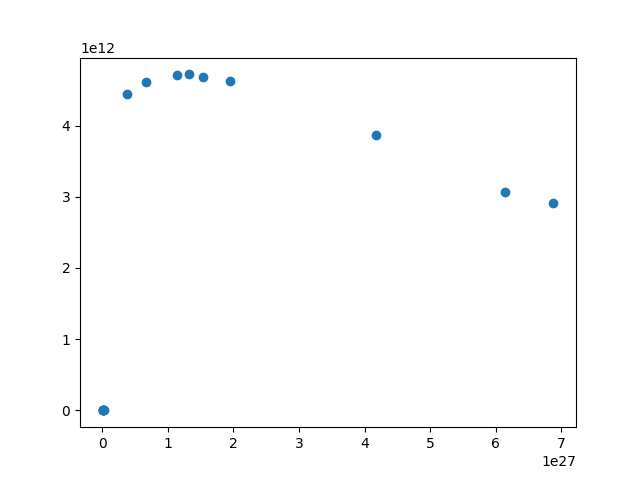

In [22]:
import random
# idx=random.randint(0, len(stars))
idx = 0
(density, reaction_rate) = stars[idx].reactions_profile()

print(f'{stars[idx].batch_idx}:{stars[idx].iteration_idx}')
fig, ax = plt.subplots()
ax.scatter(density, reaction_rate)

In [ ]:
all_densities = []
all_reaction_rates = []

for star in stars:
    (density, reaction_rate) = star.reactions_profile()
    for i in range(len(density)):
        all_densities.append(density[i])
        all_reaction_rates.append(reaction_rate[i])

all_densities = np.array(all_densities)
all_reaction_rates = np.array(all_reaction_rates)

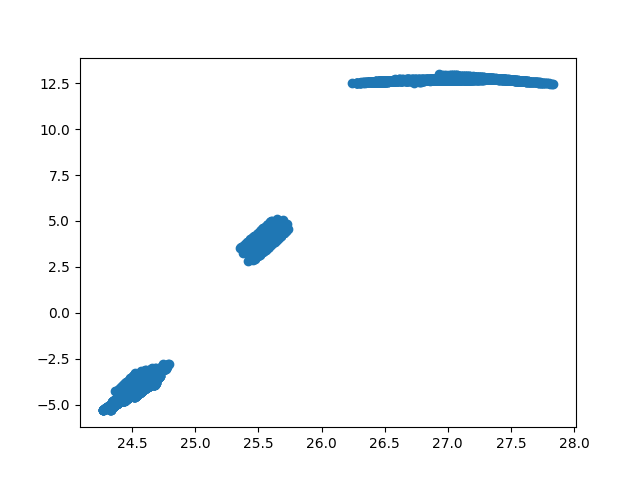

In [24]:
fig, ax = plt.subplots()
ax.scatter(x=all_densities, y=all_reaction_rates)

## Analysis method
Since different stars have different magnitudes of density and reaction rates, we are going to analyze differentials instead.

This means we will analyze the changes in reaction rates due to *changes* in either density or temperature.

We'd be trying to find the coefficients A and B in this equation:

${\partial R} = A{\partial \rho} + B{\partial T}$

Where:

$\partial R$ is the change in reaction rate,

$\partial \rho$ is the change in density,

$\partial T$ is the change in temperature,

$A$ is the coefficient for density, and is technically defined as the partial derivative of $R$ with respect to $\rho$. *i.e.* $A = \frac{\partial R}{\partial \rho}$

$B$ is the coefficient for temperature, and is the partial derivative of $R$ with respect to $T$. $B = \frac{\partial R}{\partial T}$



In [25]:
all_profiles_data = []
for star in stars:
    all_profiles_data.append(star.profile_df)

whole_df = pd.concat(all_profiles_data)
whole_df

,batch_idx,iteration_idx,mass,core_radius,radius,age,core_mass,core_volume,core_density,core_temperature,...,central_T,central_P,H,He3,He,C,N,O,Ne,Mg
0,0,0,1.591200e+30,1.047307e+09,1.047307e+09,4.719811e-03,1.591200e+30,4.811832e+27,844.068378,2.098132e+06,...,"0 6.593173 Name: log_cntr_T, dtype: float64","0 15.050203 Name: log_cntr_P, dtype: float64",0.767800,0.000023,0.219977,0.002103,0.000616,0.005722,0.001272,0.002487
1,0,0,1.591200e+30,1.047307e+09,1.047307e+09,4.549719e-01,1.591200e+30,4.811831e+27,844.068484,2.098132e+06,...,"0 6.593173 Name: log_cntr_T, dtype: float64","0 15.050203 Name: log_cntr_P, dtype: float64",0.767800,0.000023,0.219977,0.002103,0.000616,0.005722,0.001272,0.002487
2,0,0,1.591200e+30,1.047303e+09,1.047303e+09,4.340732e+01,1.591200e+30,4.811773e+27,844.078609,2.098140e+06,...,"0 6.593175 Name: log_cntr_T, dtype: float64","0 15.05021 Name: log_cntr_P, dtype: float64",0.767800,0.000023,0.219977,0.002103,0.000616,0.005722,0.001272,0.002487
3,0,0,1.591200e+30,1.046899e+09,1.046899e+09,4.140899e+03,1.591200e+30,4.806217e+27,845.044388,2.098937e+06,...,"0 6.593326 Name: log_cntr_T, dtype: float64","0 15.050876 Name: log_cntr_P, dtype: float64",0.767800,0.000023,0.219977,0.002103,0.000616,0.005722,0.001272,0.002487
4,0,0,1.591200e+30,1.011496e+09,1.011496e+09,3.950261e+05,1.591200e+30,4.334925e+27,936.134163,2.171478e+06,...,"0 6.606589 Name: log_cntr_T, dtype: float64","0 15.110671 Name: log_cntr_P, dtype: float64",0.767800,0.000023,0.219977,0.002103,0.000616,0.005722,0.001272,0.002487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,3,9,2.088450e+30,1.523519e+08,9.457588e+08,4.471655e+09,8.656634e+29,1.481264e+25,88631.076958,1.353347e+07,...,"0 7.29398 Name: log_cntr_T, dtype: float64","0 17.726806 Name: log_cntr_P, dtype: float64",0.509666,0.000097,0.477795,0.000304,0.003124,0.005255,0.001272,0.002487
11,3,9,2.088450e+30,1.516364e+08,9.935494e+08,4.845035e+09,8.656634e+29,1.460492e+25,100295.264417,1.387989e+07,...,"0 7.295723 Name: log_cntr_T, dtype: float64","0 17.834135 Name: log_cntr_P, dtype: float64",0.488106,0.000089,0.499378,0.000277,0.003284,0.005107,0.001272,0.002487
12,3,9,2.088450e+30,1.508171e+08,1.036310e+09,5.111486e+09,8.533276e+29,1.436946e+25,113988.648906,1.421745e+07,...,"0 7.298184 Name: log_cntr_T, dtype: float64","0 17.929566 Name: log_cntr_P, dtype: float64",0.468690,0.000079,0.518815,0.000238,0.003452,0.004968,0.001272,0.002487
13,3,9,2.088450e+30,1.439555e+08,1.229235e+09,5.845452e+09,7.905980e+29,1.249606e+25,222982.934577,1.549746e+07,...,"0 7.316181 Name: log_cntr_T, dtype: float64","0 18.381143 Name: log_cntr_P, dtype: float64",0.395155,0.000056,0.592424,0.000106,0.004123,0.004376,0.001272,0.002487


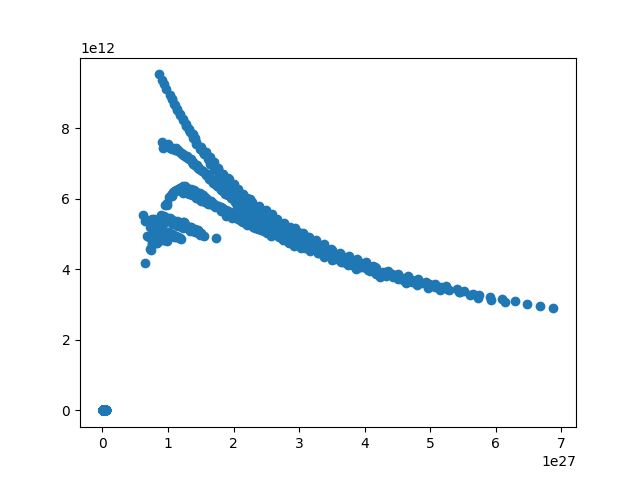

In [68]:
fig, ax = plt.subplots()

desired_mass = 1.1
data = whole_df[whole_df['reaction_rates_per_unit_volume'] > 1e12]
data = whole_df[whole_df['H'] > 0.5]

ax.scatter(data['he3_number_density'], data['reaction_rates_per_unit_volume'])

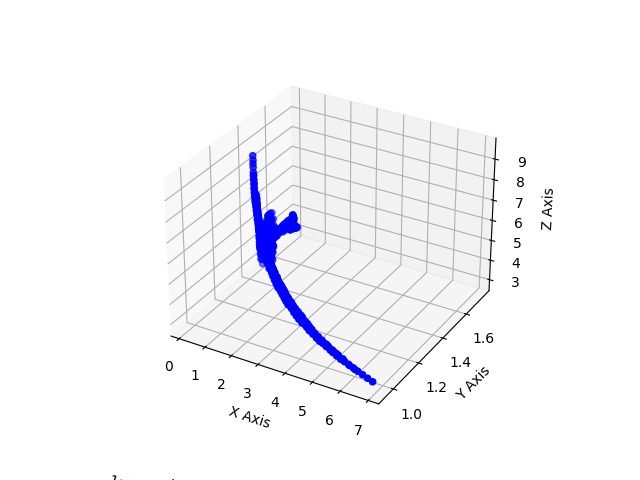

In [61]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Generate random data
x = data['he3_number_density']
y = data['core_temperature']
z = data['reaction_rates_per_unit_volume']

ax.scatter(x, y, z, c='blue', marker='o')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.show()

In [37]:
plt.close()